## Εισαγωγή στο Πρόβλημα

Σε αυτό το script, αναλύουμε ένα κλασικό σύνολο δεδομένων που χρησιμοποιείται συχνά για την εισαγωγή στους αλγορίθμους ταξινόμησης, και συγκεκριμένα στα Δέντρα Απόφασης. Το πρόβλημα αφορά την πρόβλεψη του αν μια συγκεκριμένη δραστηριότητα, το παιχνίδι τένις ("PlayTennis"), θα πραγματοποιηθεί ή όχι, με βάση τις τρέχουσες καιρικές συνθήκες.

Το σύνολο δεδομένων περιλαμβάνει παρατηρήσεις από διαφορετικές ημέρες, καταγράφοντας τις ακόλουθες καιρικές μεταβλητές:
- **Outlook (Πρόγνωση):** Sunny (Ηλιοφάνεια), Overcast (Συννεφιά), Rain (Βροχή)
- **Temperature (Θερμοκρασία):** Hot (Ζέστη), Mild (Ήπια), Cool (Δροσερή)
- **Humidity (Υγρασία):** High (Υψηλή), Normal (Κανονική)
- **Wind (Άνεμος):** Weak (Ασθενής), Strong (Ισχυρός)

Η μεταβλητή στόχος που θέλουμε να προβλέψουμε είναι το **PlayTennis**, με δύο πιθανές τιμές: Yes (Ναι, θα παίξουμε) ή No (Όχι, δεν θα παίξουμε).

Στόχος μας είναι να χτίσουμε ένα Δέντρο Απόφασης που θα μάθει από αυτά τα ιστορικά δεδομένα και θα μπορεί να προβλέψει την απόφαση "PlayTennis" για νέες, άγνωστες καιρικές συνθήκες. Θα εξερευνήσουμε τα βήματα φόρτωσης δεδομένων, προεπεξεργασίας (μετατροπή κατηγορικών μεταβλητών), εκπαίδευσης του μοντέλου Δέντρου Απόφασης, οπτικοποίησης της δομής του και αξιολόγησης της απόδοσής του.

# **Υλοποίηση δέντρου απόφασης σε Python**

**Εισαγωγή βιβλιοθηκών**

In [ ]:

%matplotlib inline
# Η εντολή είναι ειδική για Jupyter Notebook και διασφαλίζει ότι τα γραφήματα που δημιουργούνται με την βιβλιοθήκη matplotlib εμφανίζονται απευθείας στο notebook αντί να ανοίγουν σε εξωτερικά παράθυρα.
import numpy as np # Εισάγει τη βιβλιοθήκη NumPy, η οποία παρέχει υποστήριξη για πίνακες (arrays) και αριθμητικούς υπολογισμούς.
import seaborn as sns
import scipy as sp # Εισάγει τη βιβλιοθήκη SciPy, η οποία χρησιμοποιείται για επιστημονικούς υπολογισμούς.
from sklearn.model_selection import train_test_split # Εισάγει τη συνάρτηση train_test_split από τη βιβλιοθήκη scikit-learn, η οποία χρησιμοποιείται για να χωρίσει τα δεδομένα σε training και testing datasets.
from sklearn import tree # Εισάγει το υποσύνολο tree από τη βιβλιοθήκη scikit-learn, το οποίο περιλαμβάνει υλοποιήσεις αλγορίθμων δέντρου απόφασης.
from sklearn.model_selection import cross_val_score # Εισάγει τη συνάρτηση cross_val_score, η οποία υπολογίζει τα σκορ διασταυρούμενης επικύρωσης για μοντέλα μηχανικής μάθησης.
from sklearn.utils import resample # Εισάγει τη συνάρτηση resample, η οποία χρησιμοποιείται για την επαναδειγματοληψία (resampling) δεδομένων.
from sklearn.tree import DecisionTreeClassifier # Εισάγει τον ταξινομητή δέντρου απόφασης DecisionTreeClassifier από τη βιβλιοθήκη scikit-learn.
from sklearn.ensemble import RandomForestClassifier # Εισάγει τον ταξινομητή τυχαίου δάσους RandomForestClassifier, ο οποίος είναι ένας αλγόριθμος που χρησιμοποιεί πολλά δέντρα απόφασης για να βελτιώσει την ακρίβεια των προβλέψεων.
import matplotlib as mpl # Εισάγει τη βιβλιοθήκη matplotlib, που χρησιμοποιείται για τη δημιουργία γραφημάτων και οπτικοποιήσεων.
import matplotlib.cm as cm # Εισάγει το υποσύνολο cm της βιβλιοθήκης matplotlib, που παρέχει έτοιμες παλέτες χρωμάτων (colormaps) για τη δημιουργία γραφημάτων.
import matplotlib.pyplot as plt # Εισάγει το υποσύνολο pyplot από τη βιβλιοθήκη matplotlib, το οποίο παρέχει μια συλλογή συναρτήσεων για τη δημιουργία γραφημάτων.
import pandas as pd # Εισάγει τη βιβλιοθήκη pandas, η οποία χρησιμοποιείται για την επεξεργασία και ανάλυση δεδομένων, κυρίως μέσω των DataFrames.
pd.set_option('display.width', 500) # Ρυθμίζει το πλάτος εμφάνισης των DataFrames στα 500 pixels, επιτρέποντας την καλύτερη ορατότητα των δεδομένων.
pd.set_option('display.max_columns', 100) # Ορίζει τον μέγιστο αριθμό στηλών που θα εμφανίζονται σε ένα DataFrame κατά την εκτύπωση, σε 100 στήλες.
pd.set_option('display.notebook_repr_html', True) # Ενεργοποιεί την εμφάνιση των DataFrames σε μορφή HTML στο Jupyter Notebook, κάνοντάς τα πιο ευανάγνωστα.
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, accuracy_score


**"Ανέβασμα" αρχείου που περιέχει το dataset.**
Καλείται η μέθοδος upload() από το module files. Όταν εκτελείται, ανοίγει ένα παράθυρο διαλόγου στο περιβάλλον του notebook Colab, επιτρέποντάς σας να επιλέξετε και να ανεβάσετε αρχεία από τον τοπικό σας υπολογιστή.

In [ ]:
from google.colab import files # Εισάγει το module files από τη βιβλιοθήκη google.colab,
# το οποίο παρέχει διάφορες δυνατότητες για λειτουργίες αρχείων στο Google Colab.

uploaded = files.upload() # Μετά την επιλογή και το ανέβασμα ενός αρχείου, αυτό αποθηκεύεται
# σε ένα λεξικό που ονομάζεται uploaded.

Saving PlayTennis.csv to PlayTennis.csv


**Αποθήκευση dataset σε ένα dataframe**

In [ ]:
# Ανάγνωση του "ανεβασμένου" αρχείου
tennis_df = pd.read_csv('PlayTennis.csv') # Ανάγνωση ενός αρχείου CSV (Comma-Separated Values) και αποθήκευσή του σε ένα DataFrame της βιβλιοθήκης pandas.

# Εμφάνιση των πρώτων γραμμών του dataframe
print(tennis_df.head()) # Εκτυπώνει την έξοδο στην οθόνη και συγκεκριμένα τις 5 πρώτες σειρές του dataframe.


    Outlook Temperature Humidity    Wind PlayTennis
0     Sunny         Hot     High    Weak         No
1     Sunny         Hot     High  Strong         No
2  Overcast         Hot     High    Weak        Yes
3      Rain        Mild     High    Weak        Yes
4      Rain        Cool   Normal    Weak        Yes


**Μετατροπή κατηγορικών τιμών σε 0/1**

In [ ]:
tennis_data = pd.get_dummies(tennis_df, columns=['Outlook', 'Temperature', 'Humidity', 'Wind'], dtype=int)

# χρησιμοποιείται για να μετατρέψει τις
# κατηγορικές στήλες ενός DataFrame σε αριθμητικές μέσω της μεθόδου one-hot encoding
# χρησιμοποιώντας τη βιβλιοθήκη pandas.Xρησιμοποιείται για να δημιουργήσει dummy
# (ψευδώνυμα) μεταβλητές από κατηγορικές στήλες.

print(tennis_data)
# print(tennis_data.dtypes)

   PlayTennis  Outlook_Overcast  Outlook_Rain  Outlook_Sunny  Temperature_Cool  Temperature_Hot  Temperature_Mild  Humidity_High  Humidity_Normal  Wind_Strong  Wind_Weak
0          No                 0             0              1                 0                1                 0              1                0            0          1
1          No                 0             0              1                 0                1                 0              1                0            1          0
2         Yes                 1             0              0                 0                1                 0              1                0            0          1
3         Yes                 0             1              0                 0                0                 1              1                0            0          1
4         Yes                 0             1              0                 1                0                 0              0                1     

**Τα χαρακτηριστικά του προβλήματός μας**

In [ ]:
feature_names = tennis_data.drop(columns=['PlayTennis']).columns
print(pd.DataFrame(feature_names, columns=['Feature Names']))
num_features = len(feature_names)
print("Number of features: ", num_features)

      Feature Names
0  Outlook_Overcast
1      Outlook_Rain
2     Outlook_Sunny
3  Temperature_Cool
4   Temperature_Hot
5  Temperature_Mild
6     Humidity_High
7   Humidity_Normal
8       Wind_Strong
9         Wind_Weak
Number of features:  10


**Διαχωρισμός των δεδομένων μας σε X (χαρακτηριστικά) και Y (στόχος)**

In [ ]:
x_train = tennis_data.iloc[:, tennis_data.columns != 'PlayTennis'].values # Επιλέγουμε όλες τις στήλες εκτός από τη στήλη 'PlayTennis'
y_train = tennis_data['PlayTennis'].values # Επιλέγουμε τη στήλη 'PlayTennis' ως στόχο.
# print(x_train)
# print(y_train)

**Εκπαίδευση δέντρου απόφασης**

In [ ]:
dt = DecisionTreeClassifier().fit(x_train, y_train)

**Οπτικοποίηση δέντρου απόφασης**

## Gini Impurity

Το Gini είναι ένα μέτρο που χρησιμοποιείται στα δέντρα απόφασης για να μετρήσει πόσο "καθαρό" ή "ακάθαρτο" είναι ένα σύνολο δεδομένων όσον αφορά τις κλάσεις-στόχους. Χρησιμοποιείται για να αποφασίσει ποιο χαρακτηριστικό (feature) είναι το καλύτερο για τη διαίρεση (split) των δεδομένων σε έναν κόμβο του δέντρου.

Μια χαμηλή τιμή Gini σημαίνει ότι το σύνολο δεδομένων είναι πιο "καθαρό", δηλαδή οι περισσότερες παρατηρήσεις σε αυτό το σύνολο ανήκουν στην ίδια κλάση. Αντίθετα, μια υψηλή τιμή σημαίνει ότι οι παρατηρήσεις είναι πιο ανακατεμένες μεταξύ διαφορετικών κλάσεων.

Ο τύπος για το Gini είναι:

$$ Gini = 1 - \sum_{i=1}^{C} (p_i)^2 $$

όπου:
- $C$ είναι ο αριθμός των κλάσεων.
- $p_i$ είναι η αναλογία των παρατηρήσεων που ανήκουν στην κλάση $i$ στο συγκεκριμένο σύνολο δεδομένων.

Όταν το δέντρο απόφασης επιλέγει ένα χαρακτηριστικό για διαίρεση, υπολογίζει το Gini για τα σύνολα δεδομένων που προκύπτουν μετά τη διαίρεση (τα "παιδιά" του κόμβου). Ο στόχος είναι να επιλεγεί η διαίρεση που ελαχιστοποιεί το συνολικό  Gini στα παιδιά, οδηγώντας σε πιο "καθαρά" σύνολα δεδομένων σε κάθε κλάδο του δέντρου.

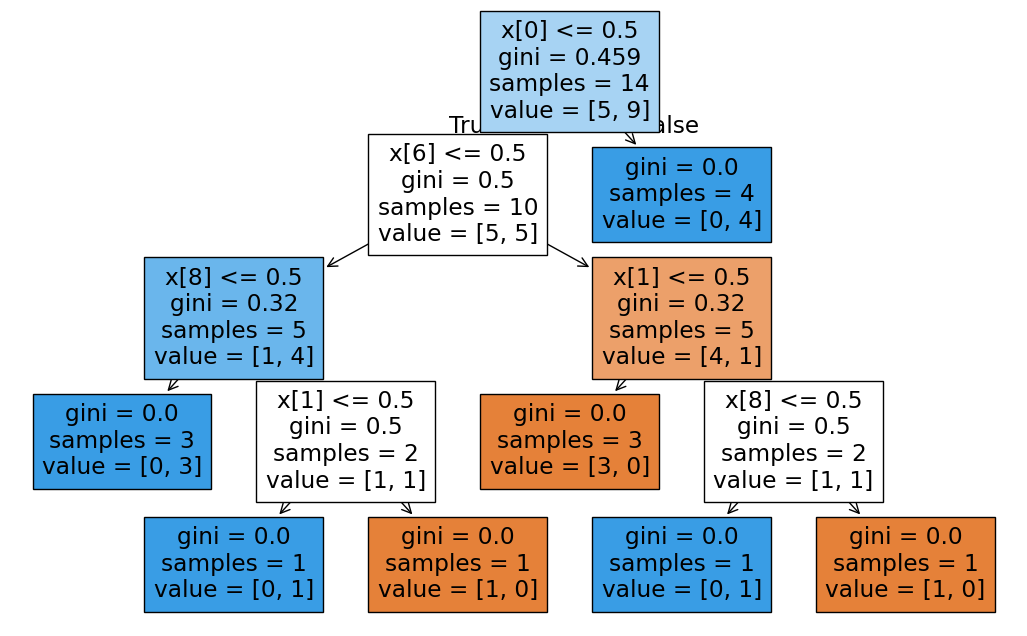

In [ ]:
plt.figure(figsize=(13, 8)) # Ορίζουμε μέγεθος γραφήματος
tree_vis = tree.plot_tree(dt, filled=True) # Δημιουργούμε γράφημα δέντρου με τα χρώματα να υποδεικνύουν την κατανομή των κλάσεων.

## Παρακάτω βλέπουμε τον πίνακα των παρατηρήσεων που απομένουν μετά από κάθε διακλάδωση-απόφαση



### Όταν η συνθήκη είναι True, τότε ακολουθείται ο αριστερός κλάδος.

In [ ]:
# Αναδρομική εμφάνιση του υπολοίπου των δεδομένων σε κάθε διάσπαση.
def display_remainder(node_index, df_remaining, tree, feature_names, depth=0):

    # Get the splitting feature and threshold
    feature_index = tree.feature[node_index]
    threshold = tree.threshold[node_index]

    if feature_index == -2: # When there's no split (end of tree)
        return

    feature_name = feature_names[feature_index]

    # Split the DataFrame based on the condition
    left_mask = df_remaining[feature_name] <= threshold
    right_mask = df_remaining[feature_name] > threshold

    left_df = df_remaining[left_mask]
    right_df = df_remaining[right_mask]

    # Print the remainder of the DataFrame at this node
    print("\t" * depth + f"Node Depth {depth}: Split on {feature_name} <= {threshold}")
    print("\t" * depth + f"Left side (<= {threshold}):")
    print(left_df)
    print("\t" * depth + f"Right side (> {threshold}):")
    print(right_df)

    # Recursively display for the left and right children
    display_remainder(tree.children_left[node_index], left_df, tree, feature_names, depth + 1)
    display_remainder(tree.children_right[node_index], right_df, tree, feature_names, depth + 1)


# Display the remainder of the DataFrame after each split
print("Displaying remainder of the dataset after each split:")
display_remainder(0, tennis_data, dt.tree_, feature_names)

Displaying remainder of the dataset after each split:
Node Depth 0: Split on Outlook_Overcast <= 0.5
Left side (<= 0.5):
   PlayTennis  Outlook_Overcast  Outlook_Rain  Outlook_Sunny  Temperature_Cool  Temperature_Hot  Temperature_Mild  Humidity_High  Humidity_Normal  Wind_Strong  Wind_Weak
0          No                 0             0              1                 0                1                 0              1                0            0          1
1          No                 0             0              1                 0                1                 0              1                0            1          0
3         Yes                 0             1              0                 0                0                 1              1                0            0          1
4         Yes                 0             1              0                 1                0                 0              0                1            0          1
5          No                

# **Άγνωστα δεδομένα**
Για δημιουργία προβλέψεων

In [ ]:
# Δημιουργία συνόλου δεδομένων για πρόβλεψη
sample_data_original = pd.DataFrame({'Outlook': ['Sunny', 'Overcast', 'Rain', 'Rain'],'Temperature': ['Hot', 'Mild', 'Cool', 'Mild'],'Humidity': ['High', 'Normal', 'Normal', 'High'],'Wind': ['Weak', 'Strong', 'Weak', 'Weak']})
print(sample_data_original)

    Outlook Temperature Humidity    Wind
0     Sunny         Hot     High    Weak
1  Overcast        Mild   Normal  Strong
2      Rain        Cool   Normal    Weak
3      Rain        Mild     High    Weak


**Μετατροπή κατηγορικών τιμών σε 0/1**

In [ ]:
sample_data_encoded = pd.get_dummies(sample_data_original, columns=['Outlook', 'Temperature', 'Humidity', 'Wind'], dtype=int)

# Reorder columns to match the training data order
sample_data_encoded = sample_data_encoded[feature_names]
print(sample_data_encoded)

   Outlook_Overcast  Outlook_Rain  Outlook_Sunny  Temperature_Cool  Temperature_Hot  Temperature_Mild  Humidity_High  Humidity_Normal  Wind_Strong  Wind_Weak
0                 0             0              1                 0                1                 0              1                0            0          1
1                 1             0              0                 0                0                 1              0                1            1          0
2                 0             1              0                 1                0                 0              0                1            0          1
3                 0             1              0                 0                0                 1              1                0            0          1


**Δημιουργία προβλέψεων**

In [ ]:
# Use the trained decision tree to predict 'PlayTennis' for the sample data
predictions = dt.predict(sample_data_encoded.values)
print(predictions)

['No' 'Yes' 'Yes' 'Yes']


**Πραγματικές** **τιμές**

In [ ]:
true_labels = ['No', 'Yes', 'Yes', 'No']
print(true_labels)

['No', 'Yes', 'Yes', 'No']


**Αξιολόγηση ταξινομητή - Υπολογισμός ακρίβειας**

In [ ]:
accuracy = accuracy_score(true_labels, predictions)
accuracy_percentage = accuracy * 100
print(f"Accuracy: {accuracy_percentage:.2f}%")

Accuracy: 75.00%


**Πίνακας συγχύσεως**

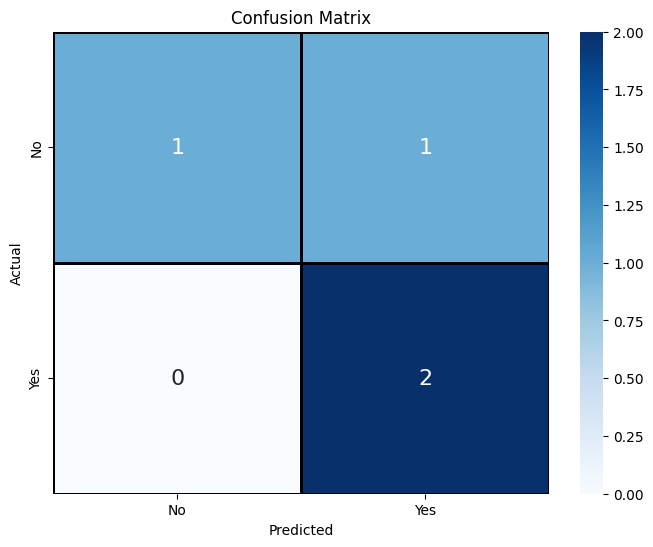

In [ ]:
cm = confusion_matrix(true_labels, predictions)
plt.figure(figsize=(8, 6))  # Adjust figure size if needed
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'],
            linewidths=1, linecolor='black', annot_kws={"size": 16})
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()